# W1-D1: Metric Anomaly Detection

Dataset: NAB `realKnownCause/ec2_request_latency_system_failure.csv`.

Mục tiêu: thực hiện EDA, implement một detector thống kê và một detector ML, sau đó so sánh precision/recall/F1 với ground-truth anomaly windows của NAB.

In [1]:
# Chạy cell này trước khi chạy phần code chính nếu môi trường chưa có đủ thư viện.
# Nếu đã cài rồi, pip sẽ báo Requirement already satisfied.
!pip install pandas numpy matplotlib scipy scikit-learn statsmodels joblib


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf

DATA_DIR = Path('data')
CSV_NAME = 'ec2_request_latency_system_failure.csv'
NAB_KEY = f'realKnownCause/{CSV_NAME}'

In [3]:
df = pd.read_csv(DATA_DIR / CSV_NAME, parse_dates=['timestamp']).sort_values('timestamp')
with open(DATA_DIR / 'combined_windows.json', encoding='utf-8') as f:
    windows = json.load(f)[NAB_KEY]

df['label'] = 0
for start, end in windows:
    mask = df['timestamp'].between(pd.to_datetime(start), pd.to_datetime(end))
    df.loc[mask, 'label'] = 1

df.head(), df.shape, windows

(            timestamp   value  label
 0 2014-03-07 03:41:00  45.868      0
 1 2014-03-07 03:46:00  47.606      0
 2 2014-03-07 03:51:00  42.580      0
 3 2014-03-07 03:56:00  46.030      0
 4 2014-03-07 04:01:00  44.992      0,
 (4032, 3),
 [['2014-03-14 03:31:00.000000', '2014-03-14 14:41:00.000000'],
  ['2014-03-18 17:06:00.000000', '2014-03-19 04:16:00.000000'],
  ['2014-03-20 21:26:00.000000', '2014-03-21 03:41:00.000000']])

## Phase 1: EDA

Em kiểm tra raw time series, thống kê cơ bản, skewness, histogram/density và ACF. Phần EDA này dùng để quyết định detector thống kê nào phù hợp nhất.

In [4]:
stats_summary = df['value'].describe()
skewness = stats.skew(df['value'])
sampling_interval = df['timestamp'].diff().dropna().mode()[0]
print(stats_summary)
print(f'skewness={skewness:.3f}')
print(f'chu ky lay mau={sampling_interval}')
print(f'so diem anomaly={df.label.sum()} / {len(df)} = {df.label.mean():.2%}')

count    4032.000000
mean       45.155874
std         2.287089
min        22.864000
25%        43.944000
50%        45.017000
75%        46.362000
max        99.248000
Name: value, dtype: float64
skewness=3.062
chu ky lay mau=0 days 00:05:00
so diem anomaly=346 / 4032 = 8.58%


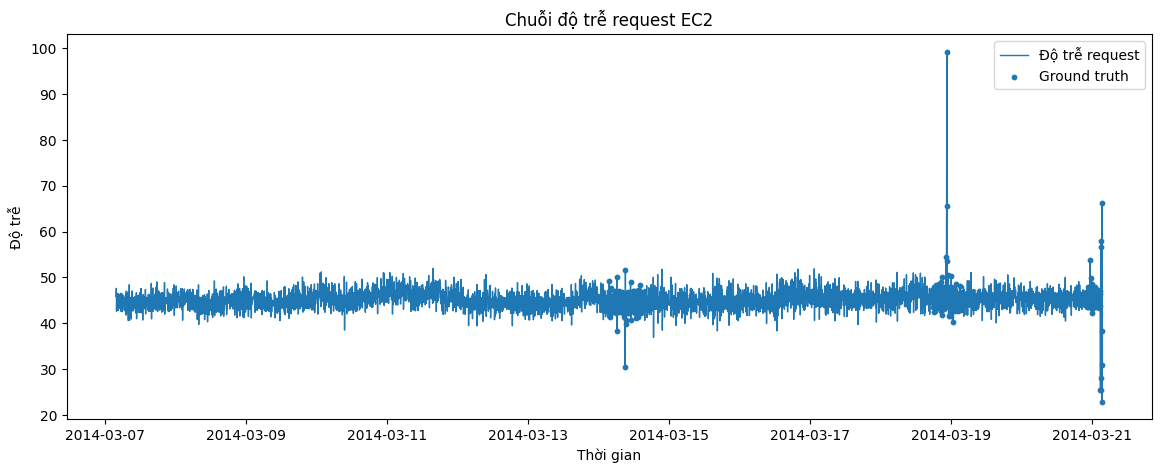

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['timestamp'], df['value'], linewidth=1, label='Độ trễ request')
ax.scatter(df.loc[df.label == 1, 'timestamp'], df.loc[df.label == 1, 'value'], s=10, label='Ground truth')
ax.set_title('Chuỗi độ trễ request EC2')
ax.set_xlabel('Thời gian')
ax.set_ylabel('Độ trễ')
ax.legend();

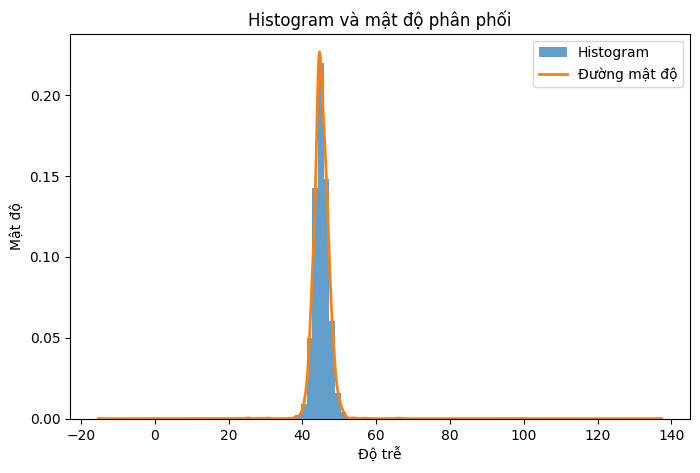

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['value'], bins=50, density=True, alpha=0.7, label='Histogram')
df['value'].plot(kind='density', ax=ax, linewidth=2, label='Đường mật độ')
ax.set_title('Histogram và mật độ phân phối')
ax.set_xlabel('Độ trễ')
ax.set_ylabel('Mật độ')
ax.legend();

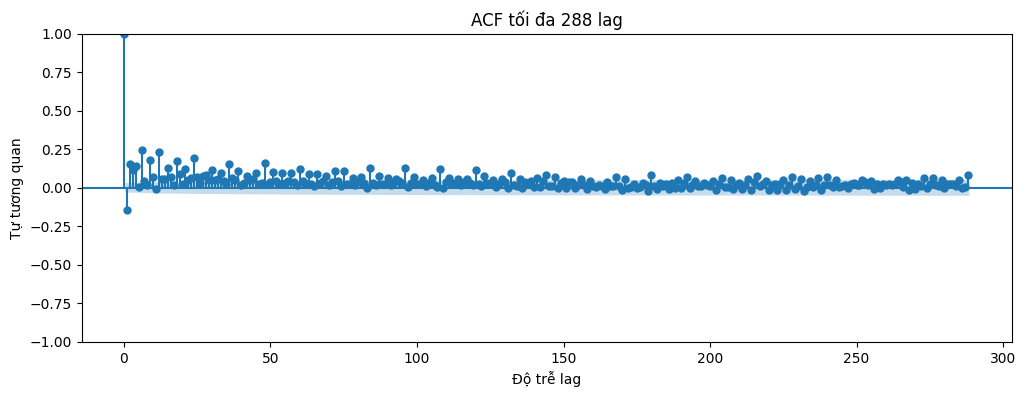

In [7]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(df['value'], lags=288, ax=ax)
ax.set_title('ACF tối đa 288 lag')
ax.set_xlabel('Độ trễ lag')
ax.set_ylabel('Tự tương quan');

### Kết luận EDA

Series latency bị lệch phải rõ rệt và có các khoảng anomaly đã được gán nhãn bởi NAB. Vì latency thường có đuôi dài ở phía giá trị cao, dùng raw 3-sigma sẽ rủi ro. Baseline thống kê phù hợp hơn là Rolling Log-IQR; Isolation Forest dùng thêm các feature theo ngữ cảnh để bắt những thay đổi hình dạng mà threshold đơn giản dễ bỏ sót.

Vì latency bị lệch phải, em không dùng raw 3-sigma trực tiếp. Em dùng Rolling IQR trên `log1p(value)` để giảm skewness và ít bị ảnh hưởng bởi outlier. Cấu hình cuối là `window=288` và `k=1.25`; cấu hình này giữ false alarms thấp hơn nhiều so với setting nhạy nhất.

## Giải thích phương pháp

### 1. Raw 3-sigma là gì và vì sao rủi ro

Raw 3-sigma là cách detect anomaly bằng mean và standard deviation trên dữ liệu gốc:

```text
upper_threshold = mean + 3 * std
lower_threshold = mean - 3 * std
```

Điểm nào vượt ngoài khoảng này thì bị coi là anomaly. Cách này hoạt động tốt nhất khi dữ liệu gần Gaussian, tức phân phối dạng chuông và khá đối xứng quanh mean.

Với latency thì assumption này thường không đúng. Đa số request nhanh, nhưng thỉnh thoảng có request rất chậm, tạo đuôi dài ở phía giá trị cao. Khi đó mean và std bị kéo bởi tail, làm threshold phía trên có thể quá lỏng và miss anomaly. Threshold phía dưới cũng ít ý nghĩa vì latency không thể âm. Vì vậy trong bài này em không chọn raw 3-sigma làm detector chính.

### 2. Dựa vào đâu nói series latency bị lệch phải và anomaly ở đâu

Có 3 bằng chứng trong EDA:

- Skewness của dataset là **3.062**. Skewness gần 0 nghĩa là khá đối xứng; skewness > 1 thường được xem là lệch phải mạnh. Vì vậy 3.062 cho thấy latency bị lệch phải rõ.
- Histogram/density cho thấy phần lớn điểm nằm ở vùng latency thấp/trung bình, nhưng có một số giá trị cao kéo dài về bên phải.
- Min/mean/max cũng cho thấy tail phía cao: mean là **45.156**, nhưng max lên tới **99.248**.

Các khoảng anomaly không phải do em tự đoán, mà lấy từ ground truth của NAB trong file `data/combined_windows.json`. Script đọc anomaly windows của dataset `realKnownCause/ec2_request_latency_system_failure.csv`, rồi gán label = 1 cho các timestamp nằm trong các khoảng đó. Tổng cộng có **346 điểm anomaly / 4032 điểm dữ liệu**, tức **8.58%**.

### 3. Vì sao Rolling Log-IQR phù hợp

Rolling Log-IQR phù hợp vì nó xử lý đúng các vấn đề của latency:

- **Log transform**: dùng `log1p(value)` để nén các giá trị rất cao, giúp giảm ảnh hưởng của right-skew.
- **IQR**: dùng Q1, Q3 và IQR thay vì mean/std, nên ít bị outlier kéo lệch hơn raw 3-sigma.
- **Rolling window**: tính threshold trên cửa sổ gần nhất thay vì dùng một threshold cố định cho toàn bộ lịch sử, nên thích nghi tốt hơn nếu baseline thay đổi theo thời gian.

Công thức IQR:

```text
Q1 = percentile 25%
Q3 = percentile 75%
IQR = Q3 - Q1
lower = Q1 - k * IQR
upper = Q3 + k * IQR
```

Trong bài này dữ liệu có chu kỳ lấy mẫu 5 phút. Em chọn `window=288`, tương đương 288 * 5 phút = 1 ngày. Em cũng tune một vài setting. Setting `k=0.5` bắt được nhiều anomaly hơn nhưng tạo tới 752 false alarms, quá nhiều cho on-call. Vì vậy em chọn `window=288, k=1.25` làm trade-off hợp lý hơn.

### 4. Isolation Forest là gì và vì sao kết luận IF tốt hơn trong lần chạy này

Isolation Forest là thuật toán ML để detect anomaly. Ý tưởng chính là: điểm bất thường thường dễ bị cô lập hơn điểm bình thường. Model tạo nhiều cây random; ở mỗi cây, nó random chọn feature và random split. Nếu một điểm rất khác phần còn lại, nó thường bị tách ra sau ít split hơn.

Nói ngắn gọn:

```text
path length ngắn = dễ cô lập = có khả năng là anomaly
path length dài = giống nhiều điểm khác = normal
```

Với time series, chỉ đưa raw value vào model là chưa đủ vì cùng một giá trị latency có thể bình thường ở thời điểm này nhưng bất thường ở thời điểm khác. Vì vậy em tạo thêm các feature context như `rolling_mean_1h`, `rolling_std_1h`, `rolling_mean_4h`, `rate_of_change`, `lag_1`, `lag_1h`, `hour`, `is_weekend`, và `z_score`.

Kết quả cuối:

| Detector | Precision | Recall | F1 | False alarms |
|---|---:|---:|---:|---:|
| Rolling Log-IQR | 0.176 | 0.095 | 0.124 | 155 |
| Isolation Forest | 0.365 | 0.211 | 0.267 | 127 |

Vì Isolation Forest có precision, recall và F1 đều cao hơn, đồng thời false alarms thấp hơn Rolling Log-IQR trong cấu hình cuối, nên em kết luận IF tốt hơn trên dataset này. Tuy nhiên điều này không có nghĩa IF luôn tốt hơn trong production. Rolling Log-IQR vẫn là baseline tốt vì dễ giải thích, dễ debug và chi phí thấp. IF phù hợp hơn khi có đủ feature context và dữ liệu lịch sử.

## Phase 2: Detector 1 - Rolling Log-IQR thống kê

In [8]:
def evaluate(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {'precision': precision, 'recall': recall, 'f1': f1, 'false_alarms': fp, 'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn}

def rolling_log_iqr_detector(values, window=288, k=1.25):
    s = pd.Series(np.log1p(values.to_numpy()), index=values.index)
    q1 = s.rolling(window, min_periods=window // 2).quantile(0.25)
    q3 = s.rolling(window, min_periods=window // 2).quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return ((s < lower) | (s > upper)).fillna(False).astype(int)

stat_tuning_rows = []
for window, k in [(144, 1.5), (288, 1.25), (288, 0.5)]:
    pred = rolling_log_iqr_detector(df['value'], window=window, k=k)
    stat_tuning_rows.append({'window': window, 'k': k, **evaluate(df['label'], pred)})
pd.DataFrame(stat_tuning_rows)

df['pred_iqr'] = rolling_log_iqr_detector(df['value'], window=288, k=1.25)
evaluate(df['label'], df['pred_iqr'])

{'precision': 0.17553191489361702,
 'recall': 0.0953757225433526,
 'f1': 0.12359550561797752,
 'false_alarms': np.int64(155),
 'tp': np.int64(33),
 'fp': np.int64(155),
 'fn': np.int64(313),
 'tn': np.int64(3531)}

## Phase 2: Detector 2 - Isolation Forest

In [9]:
def build_features(series, timestamps, window=12):
    s = pd.Series(series.to_numpy(), index=series.index)
    ts = pd.to_datetime(timestamps)
    rolling_mean = s.rolling(window).mean()
    rolling_std = s.rolling(window).std().replace(0, 1e-10)
    features = pd.DataFrame({
        'value': s,
        'log_value': np.log1p(s),
        'rolling_mean_1h': rolling_mean,
        'rolling_std_1h': rolling_std,
        'rolling_mean_4h': s.rolling(window * 4).mean(),
        'rolling_std_4h': s.rolling(window * 4).std(),
        'rate_of_change': s.diff(),
        'rate_of_change_15m': s.diff(3),
        'lag_1': s.shift(1),
        'lag_1h': s.shift(window),
        'hour': pd.Series(ts.dt.hour.to_numpy(), index=s.index),
        'is_weekend': pd.Series((ts.dt.dayofweek >= 5).astype(int).to_numpy(), index=s.index),
        'z_score': (s - rolling_mean) / rolling_std,
    })
    return features.replace([np.inf, -np.inf], np.nan).dropna()

features = build_features(df['value'], df['timestamp'], window=12)
labels = df.loc[features.index, 'label']
features.head()

,value,log_value,rolling_mean_1h,rolling_std_1h,rolling_mean_4h,rolling_std_4h,rate_of_change,rate_of_change_15m,lag_1,lag_1h,hour,is_weekend,z_score
47,46.110,3.852485,44.624000,1.797606,44.783458,1.525378,2.330,3.998,43.780,44.320,7,0,0.826655
48,43.662,3.799123,44.536000,1.818315,44.737500,1.525238,-2.448,-0.188,46.110,44.718,7,0,-0.480665
49,46.808,3.867193,44.631833,1.910779,44.720875,1.497402,3.146,3.028,43.662,45.658,7,0,1.138890
50,40.586,3.727764,44.461500,2.177887,44.679333,1.583257,-6.222,-5.524,46.808,42.630,7,0,-1.779477
51,45.870,3.847378,44.410833,2.133326,44.676000,1.580519,5.284,2.208,40.586,46.478,7,0,0.683987


In [10]:
scaler = StandardScaler()
X = scaler.fit_transform(features)
tuning_rows = []
models = {}
for contamination in [0.01, 0.02, 0.05]:
    model = IsolationForest(n_estimators=300, contamination=contamination, random_state=42)
    pred = (model.fit_predict(X) == -1).astype(int)
    metrics = evaluate(labels, pred)
    tuning_rows.append({'contamination': contamination, **metrics})
    models[contamination] = model
pd.DataFrame(tuning_rows)

,contamination,precision,recall,f1,false_alarms,tp,fp,fn,tn
0,0.01,0.8250,0.095376,0.170984,7,33,7,313,3632
1,0.02,0.6125,0.141618,0.230047,31,49,31,297,3608
2,0.05,0.3650,0.210983,0.267399,127,73,127,273,3512


In [11]:
best_contamination = 0.05
best_model = models[best_contamination]
df['pred_if'] = 0
df.loc[features.index, 'pred_if'] = (best_model.predict(X) == -1).astype(int)
evaluate(df['label'], df['pred_if'])

{'precision': 0.365,
 'recall': 0.21098265895953758,
 'f1': 0.2673992673992674,
 'false_alarms': np.int64(127),
 'tp': np.int64(73),
 'fp': np.int64(127),
 'fn': np.int64(273),
 'tn': np.int64(3559)}

## Phase 3: So sánh kết quả

| Chỉ số | Rolling Log-IQR | Isolation Forest |
|---|---:|---:|
| Precision | 0.176 | 0.365 |
| Recall | 0.095 | 0.211 |
| F1 | 0.124 | 0.267 |
| False alarms | 155 | 127 |

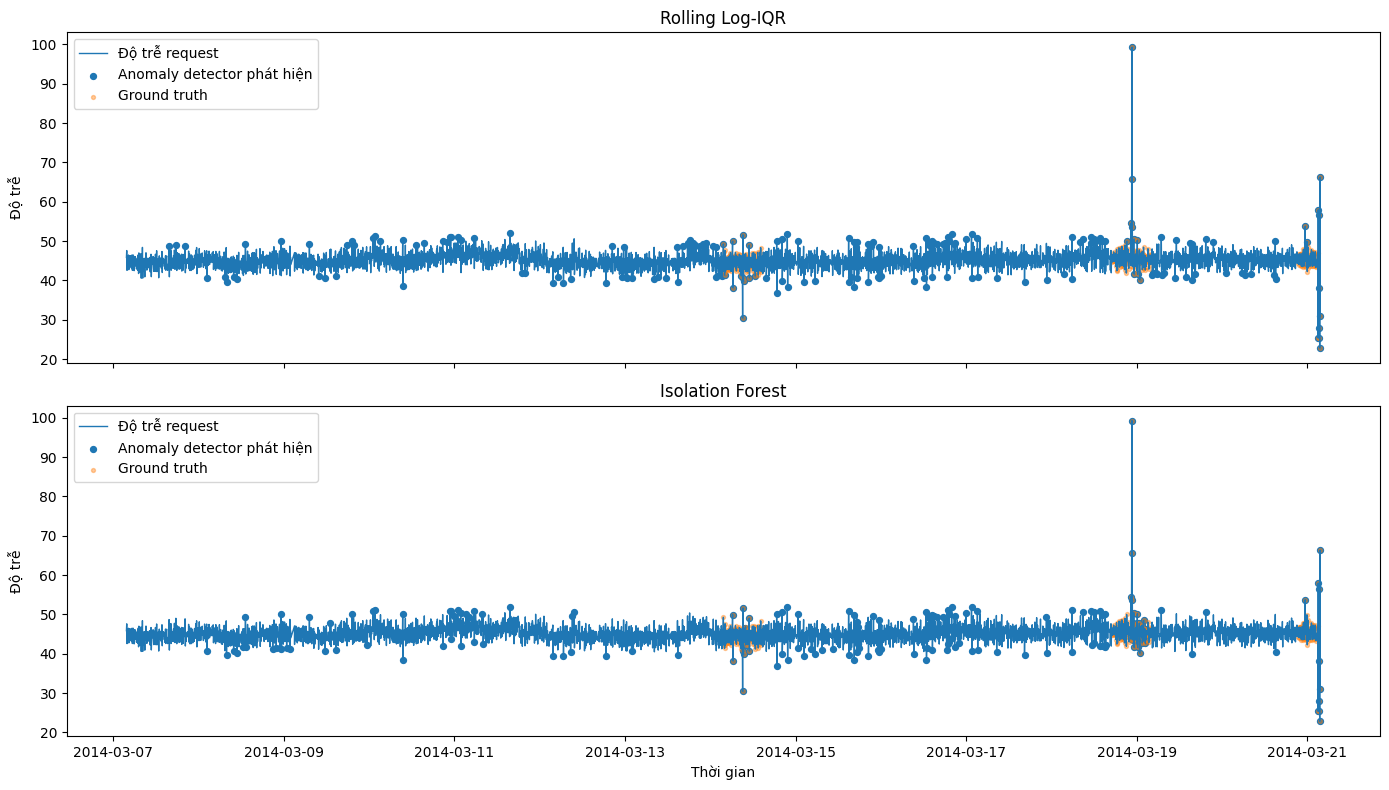

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for ax, col, title in [
    (axes[0], 'pred_iqr', 'Rolling Log-IQR'),
    (axes[1], 'pred_if', 'Isolation Forest'),
]:
    ax.plot(df['timestamp'], df['value'], linewidth=1, label='Độ trễ request')
    ax.scatter(df.loc[df[col] == 1, 'timestamp'], df.loc[df[col] == 1, 'value'], s=18, label='Anomaly detector phát hiện')
    ax.scatter(df.loc[df.label == 1, 'timestamp'], df.loc[df.label == 1, 'value'], s=8, alpha=0.4, label='Ground truth')
    ax.set_title(title)
    ax.set_ylabel('Độ trễ')
    ax.legend()
axes[-1].set_xlabel('Thời gian')
plt.tight_layout();

## Reflection

Dataset này giống một metric latency thực tế: phân phối không Gaussian, bị lệch phải mạnh với skewness=3.062, nên raw 3-sigma không phải lựa chọn tốt nhất. Rolling Log-IQR dễ giải thích, chi phí thấp và robust với skew, nhưng chỉ nhìn một metric nên còn miss nhiều contextual anomaly. Isolation Forest dùng các feature theo ngữ cảnh như rolling mean, rolling std, lag, rate of change, hour và z-score. Isolation Forest có F1 tốt hơn trong lần chạy này. Nếu đưa vào production AIOps, em sẽ ưu tiên recall cho metric quan trọng như latency/error rate, sau đó kiểm soát alert fatigue bằng correlation, service ownership và severity routing.

Nếu đưa vào production AIOps, em sẽ bắt đầu với Rolling Log-IQR làm baseline vì dễ giải thích và chi phí thấp. Khi có nhiều metric liên quan hoặc đủ dữ liệu lịch sử, em sẽ chạy Isolation Forest song song để bắt contextual anomaly tốt hơn.

## Tóm tắt kết quả

| Hạng mục | Kết quả |
|---|---:|
| Dataset | `realKnownCause/ec2_request_latency_system_failure.csv` |
| Số điểm dữ liệu | 4032 |
| Chu kỳ lấy mẫu | 5 phút |
| Điểm anomaly theo ground truth | 346 |
| Tỷ lệ anomaly | 8.58% |
| Mean latency | 45.156 |
| Standard deviation | 2.287 |
| Min latency | 22.864 |
| Max latency | 99.248 |
| Skewness | 3.062 |

| Detector | Precision | Recall | F1 | False alarms | TP | FP | FN | TN |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Rolling Log-IQR | 0.176 | 0.095 | 0.124 | 155 | 33 | 155 | 313 | 3531 |
| Isolation Forest | 0.365 | 0.211 | 0.267 | 127 | 73 | 127 | 273 | 3559 |

**Kết luận ngắn:** Dataset latency bị lệch phải mạnh, nên raw 3-sigma không phải lựa chọn phù hợp. Rolling Log-IQR là baseline dễ giải thích và robust hơn với skew. Isolation Forest cho kết quả tốt hơn trong lần chạy này vì dùng thêm feature context của time series.